# Phase 1: Data Preparation and Filtering

This notebook focuses on filtering and tagging the dataset to separate "easy" from "hard" samples for gender identification. The goal is to build a curated dataset where gender cannot be trivially inferred from explicit markers.

**Strategy:**
1. **TF-IDF + Linear SVM**: Use a simple baseline model to identify samples that are easily classified (explicit gender markers)
2. **LLM-based filtering**: Use an LLM to tag remaining samples based on whether they contain trivial gender indicators

This preparation is crucial for the next phases where we will study how LLM weights behave when identifying gender from prompts without obvious markers.

## Loading the cleaned dataset

We start by loading the pre-processed dataset from Phase 0. The `load_raw_dataset` function handles all the cleaning steps we defined earlier (removing NaN, filtering by token count, removing special characters).

In [1]:
from utils.dataset_loader import load_raw_dataset
import pandas as pd

df = load_raw_dataset()

In [2]:
df.head()

,gender,text,user_id
0,male,DESTINY... you might not say anything but i ca...,4162441
1,male,"DEAR ANGEL.. you say it or you don't, but i ca...",4162441
2,male,MAIN AUR MERI TANHAI (jagjeet singh) awara hai...,4162441
3,male,mail addressrs(s) http://rediff.com http://sif...,4162441
4,male,RAP- ALLRISE so stand back cause u don't notic...,4162441


In [3]:
df.shape

(612203, 3)

## TF-IDF Baseline Model

We first apply TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to convert text into numerical features. This will allow us to train a simple linear classifier to identify samples with obvious gender markers.

**Parameters:**
- `min_df=5`: Ignore terms that appear in fewer than 5 documents
- `max_features=10000`: Keep only the top 10,000 features

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    min_df=5,
    max_features=10000
)
X = vectorizer.fit_transform(df['text'])

In [5]:
import numpy as np
np.random.choice(vectorizer.get_feature_names_out(), 100)

array(['hopeless', 'neighbours', 'pledge', 'travel', 'possibilities',
       'george', 'dusty', 'context', 'results', 'newly', 'apparently',
       'healthy', 'abc', 'buying', 'terrorists', 'spectacular',
       'reported', 'private', 'asleep', 'laid', 'thought', 'worldwide',
       'lands', 'melissa', 'grin', 'mandarin', 'choices', 'elsewhere',
       'departure', 'samuel', 'arnold', 'consumer', 'hungry', 'eagles',
       'critic', 'picking', 'discovering', 'shops', 'luxury', 'joked',
       'terrorism', 'continue', 'gifted', 'safe', 'nominated', 'superior',
       'approved', 'hrs', 'predicted', 'aid', 'cock', 'evan', 'boss',
       'hampshire', 'testament', 'compliment', 'finally', 'bent', 'about',
       'trainer', 'trio', 'derek', '8pm', 'secretary', 'shell', 'spider',
       'outline', 'objective', 'eugene', 'brunch', 'master', 'login',
       'seen', 'exposure', 'pen', 'tow', 'revolutionary', 'afterwards',
       'dealer', 'commander', 'moving', 'oneself', 'joan', 'lake',
      

In [6]:
vectorizer.get_feature_names_out().shape

(10000,)

### Training a Linear SVM classifier

We use a Linear Support Vector Classifier as our baseline. This model is fast and works well with TF-IDF features. The goal is not to build the best classifier, but to identify which samples are "easy" to classify based on word patterns.

In [7]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['gender'], test_size=0.1, random_state=42)
X_train.shape, X_test.shape

((550982,), (61221,))

In [8]:
y_test.value_counts()

gender
male      31092
female    30129
Name: count, dtype: int64

In [9]:
model = LinearSVC()
model = model.fit(vectorizer.transform(X_train), y_train)

In [10]:
model.score(vectorizer.transform(X_test), y_test)

0.6910700576599533

The model achieves a decent accuracy on the test set. This confirms that many samples contain explicit gender markers that make classification straightforward.

### Analyzing misclassified samples

The samples that the model gets wrong are particularly interesting for our study. These are the "hard" cases where gender cannot be easily inferred from word patterns alone.

In [11]:
y_pred = model.predict(vectorizer.transform(X_test[:100]))
y_true = y_test[:100]

In [12]:
X_test[X_test.index.isin(y_true[y_true != y_pred].index)]

584915    When I first moved to Baltimore, my maintenanc...
163180                                   me want yogi cave!
19945     I don't know about that...Fonz's response had ...
156928                               this kid is crazy.....
556616    "To look life in the face, to know it for what...
382074                   oh and a fell asleep in the street
125903    The titles makes it difficult to blog because ...
420798    you can't write if you don't read. -Sashi Mi S...
570981    hmmm faveorite songs??? Chop Suey- system of a...
196239    At least I care for my bleeps. Beep. Yay! Have...
551386    Today I did a little research on what makes a ...
365644    Angelica, 2, needs a liver transplant By Joyce...
9143      This is just a short post advising all visitor...
77401     okay, i just found out that the building close...
641495    sorrry about the loooong delay. also sorry abo...
416228    Ok, what happened? Where's Josh's blog? It was...
288372    I know this is an oldie...but 

In [13]:
y_test.loc[146638]

'male'

In [14]:
y_pred = model.predict(vectorizer.transform(X_test))
y_true = y_test

<Axes: xlabel='text', ylabel='Count'>

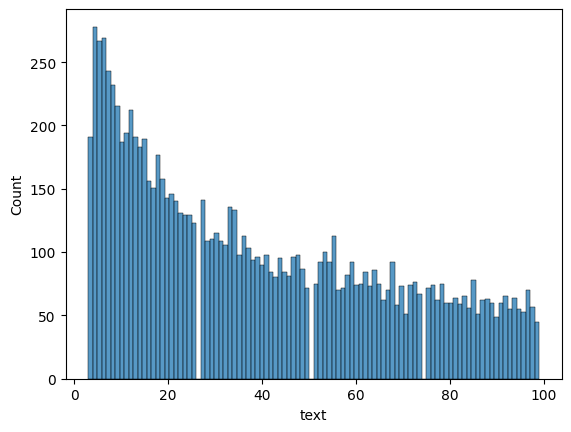

In [15]:
import seaborn as sns


X_test_wrong = X_test[X_test.index.isin(y_true[y_true != y_pred].index)]
X_test_len = X_test[X_test.index.isin(y_true[y_true != y_pred].index)].str.split(' ').apply(len)

sns.histplot(X_test_len[X_test_len < 100], bins=100)

### Distribution of misclassified samples by length

Let's see if there's a correlation between text length and misclassification. Shorter texts might lack enough context for the model to make a correct prediction.

In [16]:
X_test.loc[X_test_len[X_test_len == 5].index]

173683    Harrumph.... rgh ghg rght. YYEEEHHHAAAA!
611692                    11/23/2003 - New Roomie 
600474                 Rice fields of NE Macedonia
441824              Snowstorm in April? The heck?!
288564            GETTIN.... DRUNK DRUNK DRUNK!!! 
                            ...                   
583055                     STUFF ON MY CUCHITRILL 
611693                11/23/2004 - Original Plans 
541687      BillOReilly.com: Articles - Hating Mel
609740                 I'm Really Down With Flu...
268831                    I'm bored... What to do?
Name: text, Length: 267, dtype: object

In [17]:
y_test.loc[470347]

'male'

In [18]:
y_test.value_counts()

gender
male      31092
female    30129
Name: count, dtype: int64

In [19]:
y_test.shape

(61221,)

## LLM-based filtering

The TF-IDF baseline gives us a first layer of filtering. Now we want to go deeper and use an LLM to detect samples where gender can be trivially identified through explicit mentions (as "I am a woman", "my boyfriend", etc.).

We define a prompt that asks the LLM to identify obvious gender markers in the text.

In [20]:
import ollama

def query_ollama(sys_prompt: str, content: str, model="gemma3:12b"):
    try:
        response = ollama.generate(model=model, prompt=sys_prompt.replace('{CONTENT}', content))
        return response.response
    except Exception as e:
        return f"Error querying Ollama: {str(e)}"

In [21]:
sys_prompt = """
**Instructions**
In the following text, determine if there is any obvious words or expressions that can be used to deduce the author's gender of the text.

**Output**
Ouput you answer with the following JSON schema:
- score is either 0 or 1: 0 when you could not find any trivial word for identifying the gender, 1 otherwise
- gender is either "female", "male" or "unknown": this is the gender you identified from the text
- reason: write down few words from the text that guided your answer
Output example:
{"score": 1, "gender": "female", "reason": "..."}
Output ONLY the JSON schema, nothing else.

Now here is the text you have to analyze:
```
{CONTENT}
```
"""

### LLM Prompt design

The prompt asks the LLM to:
1. Identify if there are obvious words/expressions that reveal the author's gender
2. Return a structured JSON response with a score (0 or 1), the identified gender, and the reason

In [22]:
def try_filter_sample(i: int, model: str = "gemma3:12b"):
    gender = y_test.iloc[i]
    text = X_test.iloc[i]
    print(f'Text (gender={gender}):')
    print(text)
    llm_answer = query_ollama(sys_prompt, text, model)
    print(f'LLM Answer: {llm_answer}')

### Testing the LLM filter on individual samples

Before applying the LLM filter to the full dataset, we test it on a few samples to verify it works as expected.

In [23]:
try_filter_sample(23823, model="gemma3:12b")

Text (gender=female):
Well today was better than I expected. Afterall the Bio quiz wasn't as scary as I thought, and I am pretty sure that I did good on it. Although the little experiment thing we did I found like really confusing, so I had to ask Brent after class about it cause I had no idea what was going on. After like 5 explanations from him I finally understood it, and afterall it wasn't as hard as it seemed. That is why I didn't ask the teacher in the first place. Sometimes I feel that I am just annoying, always asking questions, though maybe I am just super paranoid. English was good. We finished watched Good Morning Vietnam and now we are watched Billy Elliot for film study. Though I am kind of worried cause on the ucourses site my average shows up as 0% with a comment mark entered. Everyone knows I don't have 0 and when I asked my base teacher what I got she told me that I had an 84%, and well prouxl told me that something about the English is messed up because on another gir

### Building the "hard" dataset

We now focus on the samples that were misclassified by the TF-IDF baseline. These are the candidates for our "hard" dataset where gender identification is not straightforward.

In [24]:
df_hard = df[df.index.isin(X_test_wrong.index)]

In [25]:
df_hard.shape

(18913, 3)

In [26]:
df_hard_small = df_hard.head(10)

In [27]:
import json 

def add_llm_features(df: pd.DataFrame, model: str = "gemma3:12b", debug: bool = False):
    def predict_llm(row):
        text = row['text']
        true_gender = row['gender']
        try:
            llm_answer = query_ollama(sys_prompt, text, model)
            llm_answer = llm_answer.replace('```json', '').replace('```', '').strip()
            answer = json.loads(llm_answer)
            if debug:
                print(answer)

            if answer['gender'] != true_gender:
                return 0

            return int(answer['score'])
        except Exception:
            return -1

    df['trivial_gender_mark'] = df.apply(predict_llm, axis=1)
    return df

df_hsf = add_llm_features(df_hard_small, model="gpt-oss:120b-cloud", debug=True) 
df_hsf

{'score': 0, 'gender': 'unknown', 'reason': 'No gender‑specific words or expressions (e.g., he/she, wife/husband, etc.) are present in the text.'}
{'score': 0, 'gender': 'unknown', 'reason': "The text contains no self‑referential gendered words; pronouns like 'her' refer to the bird, not to the author, so author gender cannot be deduced."}
{'score': 1, 'gender': 'female', 'reason': 'Uses phrase "Chicks rule!" and mentions wanting to attend Lilith Fair, both suggesting a female perspective'}
{'score': 0, 'gender': 'unknown', 'reason': 'No explicit self‑referential gender markers; only references to mother and other females, but author does not state their own gender.'}
{'score': 0, 'gender': 'unknown', 'reason': 'No explicit gendered words or expressions like "girl", "boy", or clear self-identification; only neutral slang (e.g., "man") that doesn\'t reliably indicate gender.'}
{'score': 0, 'gender': 'unknown', 'reason': 'No gender‑specific pronouns, names, or expressions appear in the t

/var/folders/wq/x_xyd9zs6lg2rp3__2pvlg240000gn/T/ipykernel_11877/705639165.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trivial_gender_mark'] = df.apply(predict_llm, axis=1)


,gender,text,user_id,trivial_gender_mark
6,male,HAZEL EYES. close your eyes and imagine a lake...,4162441,0
7,male,LET IT BE ME. a bird hibernated for a year or ...,4162441,0
36,female,It's my first Mambo! So let's get ourselves ...,3489929,1
84,male,Mum had tore a leg ligament and broke her smal...,3364931,0
90,male,When you'd cry i'd wipe away all of your tears...,3364931,0
121,female,"I have discovered Krispey Kremes donuts, and t...",3162067,0
169,female,"I know, another quote...but I especially like ...",813360,0
239,female,I am so over Kevin. But as for the Carmicheal ...,4028373,0
278,male,Hmmmm. I'll try to re-capture my fleeting thou...,3630901,0
302,male,Porcelain by Moby (The Beach Soundtrack) .... ...,3630901,0
